# OPIM 348 — Homework 2
**Software:** Python 3, pandas, numpy, scipy, scikit-learn, statsmodels (`ExponentialSmoothing`), matplotlib.
**Rounding:** reported statistics to 2 decimals; bookings rounded to the nearest whole minute; Q, R and safety stock rounded **up** to whole units.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
from scipy.stats import norm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
warnings.filterwarnings("ignore")
pd.set_option("display.precision", 2)
plt.rcParams["figure.figsize"] = (10, 4)
# House style: teal / burnt orange / violet, slate ink, dashed grid, no top/right spines
TEAL, ORANGE, VIOLET, INK, MUTED = "#0D9488", "#C2410C", "#7C3AED", "#334155", "#94A3B8"
plt.rcParams.update({
    "font.family": "DejaVu Serif", "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.edgecolor": MUTED, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": INK, "ytick.color": INK, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#CBD5E1", "grid.linestyle": "--", "grid.linewidth": 0.6,
    "axes.facecolor": "#FAFAF7", "figure.facecolor": "white", "legend.frameon": False,
    "axes.prop_cycle": plt.cycler(color=[TEAL, ORANGE, VIOLET]),
})

# Question 1 — Operating room booking

## 1a. Actual occupancy D

In [2]:
url = "https://raw.githubusercontent.com/xuliang-leon/opim348-public-data/main/week05/2022_Q1_OR_Utilization.xlsx"
wk05_raw_df = pd.read_excel(url, sheet_name="2022_Q1")
df = wk05_raw_df.copy()
df["D"] = (df["Wheels Out"] - df["Wheels In"]).dt.total_seconds() / 60
# usable = non-missing timestamps and positive duration
df = df[df["D"].notna() & (df["D"] > 0)].copy()
df["weekday"] = df["Date"].dt.day_name()
print("Usable encounters:", len(df))
print(f"Mean D = {df['D'].mean():.2f} min, SD D = {df['D'].std():.2f} min")

Usable encounters: 2172
Mean D = 79.70 min, SD D = 31.82 min


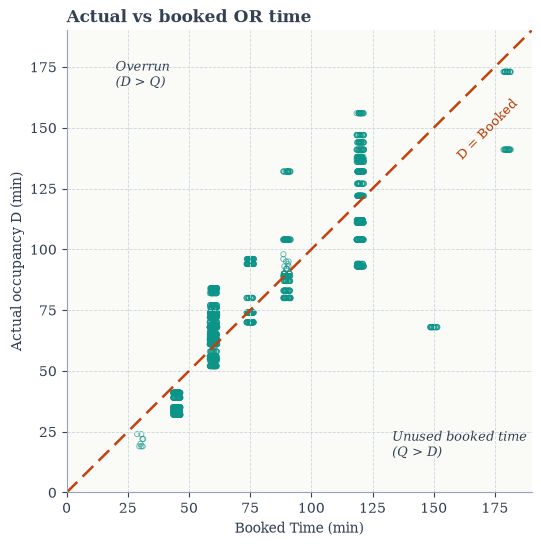

Share of cases overrunning their booking: 0.57


In [3]:
fig, ax = plt.subplots(figsize=(6, 6))
jit = np.random.default_rng(0).uniform(-1.5, 1.5, len(df))   # small horizontal jitter so stacked bookings are visible
ax.scatter(df["Booked Time (min)"] + jit, df["D"], s=14, facecolors="none", edgecolors=TEAL, linewidths=0.7, alpha=0.6)
lim = [0, max(df["Booked Time (min)"].max(), df["D"].max()) + 10]
ax.plot(lim, lim, color=ORANGE, lw=1.8, ls=(0, (6, 3)))
ax.text(lim[1] * 0.97, lim[1] * 0.84, "D = Booked", color=ORANGE, ha="right", fontsize=9, rotation=45, rotation_mode="anchor")
ax.text(20, lim[1] * 0.88, "Overrun\n(D > Q)", color=INK, fontsize=9, style="italic")
ax.text(lim[1] * 0.70, 15, "Unused booked time\n(Q > D)", color=INK, fontsize=9, style="italic")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("Booked Time (min)"); ax.set_ylabel("Actual occupancy D (min)")
ax.set_title("Actual vs booked OR time"); plt.show()
print("Share of cases overrunning their booking:", round((df['D'] > df['Booked Time (min)']).mean(), 3))

## 1b. Mismatch cost and critical ratio
$$C(Q,D) = 100\,\max(Q-D,0) + 50\,\max(D-Q,0)$$

Overage cost $C_o = 100$ (unused minute), underage cost $C_u = 50$ (overrun minute).
Critical ratio $= \dfrac{C_u}{C_u + C_o} = \dfrac{50}{150} = 1/3$. The optimal booking is the 33.3% quantile of D.
Since $1/3 < 0.5$, and for a symmetric (e.g., Normal) predictive distribution the mean equals the median, the optimal booking is **below** the predicted mean:
idle booked time costs twice as much as overrun, so we deliberately book short.

In [4]:
Co, Cu = 100, 50
CR = Cu / (Cu + Co)
z = norm.ppf(CR)
print(f"Critical ratio = {CR:.4f}, z = {z:.4f}")
def mismatch_cost(Q, D):
    return Co * np.maximum(Q - D, 0) + Cu * np.maximum(D - Q, 0)

Critical ratio = 0.3333, z = -0.4307


## 1c. Linear regression on categorical CPT Code, OR Suite, weekday

In [5]:
X = df[["CPT Code", "OR Suite", "weekday"]].astype(str)
y = df["D"]
X_tr, X_te, y_tr, y_te, idx_tr, idx_te = train_test_split(X, y, df.index, test_size=0.2, random_state=42)
model = Pipeline([
    ("enc", ColumnTransformer([("oh", OneHotEncoder(handle_unknown="ignore"), ["CPT Code", "OR Suite", "weekday"])])),
    ("lr", LinearRegression()),
])
model.fit(X_tr, y_tr)          # encoder is fit on training rows only
pred_te = model.predict(X_te)
mae = mean_absolute_error(y_te, pred_te)
rmse = np.sqrt(mean_squared_error(y_te, pred_te))
print(f"Train n = {len(X_tr)}, Test n = {len(X_te)}")
print(f"Test MAE = {mae:.2f} min, Test RMSE = {rmse:.2f} min")
print("Test CPT codes unseen in training:", (~X_te['CPT Code'].isin(X_tr['CPT Code'])).sum())

Train n = 1737, Test n = 435
Test MAE = 4.89 min, Test RMSE = 7.47 min
Test CPT codes unseen in training: 0


## 1d. Cost-based bookings
Residual SD estimated on training residuals: $\hat\sigma = \sqrt{\sum (y_i-\hat y_i)^2/(n-p)}$ where $p$ = number of fitted coefficients (incl. intercept).

Booking for test case $j$: $Q_j = \hat\mu_j + z_{1/3}\,\hat\sigma$, with $z_{1/3} = \Phi^{-1}(1/3) \approx -0.431$.
**Rounding rule:** round $Q_j$ to the nearest whole minute and floor at 0.

In [6]:
res_tr = y_tr - model.predict(X_tr)
p = model.named_steps["lr"].coef_.size + 1
sigma = np.sqrt((res_tr ** 2).sum() / (len(res_tr) - p))
print(f"Training residual SD = {sigma:.2f} min (df-adjusted; p = {p}); plain SD = {res_tr.std():.2f}")

test = df.loc[idx_te, ["CPT Code", "Booked Time (min)", "D"]].copy()
test["Q_hist"] = test["Booked Time (min)"]
test["Q_mean"] = np.maximum(np.round(pred_te), 0)
test["Q_cost"] = np.maximum(np.round(pred_te + z * sigma), 0)
# Sensitivity (beyond the three required policies): shift by the empirical 1/3 quantile of TRAINING residuals
q_emp_res = np.quantile(res_tr, CR)
test["Q_emp"] = np.maximum(np.round(pred_te + q_emp_res), 0)
print(f"Normal shift z*sigma = {z*sigma:.2f} min; empirical 1/3 quantile of training residuals = {q_emp_res:.2f} min")

rows = []
for name, col in [("Historical booking", "Q_hist"), ("Predicted mean", "Q_mean"), ("Cost-based (CR=1/3)", "Q_cost"), ("Sensitivity: empirical-quantile", "Q_emp")]:
    Q, D = test[col], test["D"]
    rows.append({"Policy": name,
                 "Total cost ($)": mismatch_cost(Q, D).sum(),
                 "Avg cost/case ($)": mismatch_cost(Q, D).mean(),
                 "Unused min": np.maximum(Q - D, 0).sum(),
                 "Overrun min": np.maximum(D - Q, 0).sum(),
                 "% cases overrun": 100 * (D > Q).mean()})
q1_tab = pd.DataFrame(rows).set_index("Policy")
q1_tab["Savings vs historical ($)"] = q1_tab.loc["Historical booking", "Total cost ($)"] - q1_tab["Total cost ($)"]
q1_tab.round(2)

Training residual SD = 7.42 min (df-adjusted; p = 46); plain SD = 7.32
Normal shift z*sigma = -3.20 min; empirical 1/3 quantile of training residuals = -1.98 min


,Total cost ($),Avg cost/case ($),Unused min,Overrun min,% cases overrun,Savings vs historical ($)
Policy,,,,,,
Historical booking,336400.0,773.33,1755.0,3218.0,61.38,0.0
Predicted mean,149650.0,344.02,873.0,1247.0,42.76,186750.0
Cost-based (CR=1/3),149700.0,344.14,421.0,2152.0,79.08,186700.0
Sensitivity: empirical-quantile,140300.0,322.53,522.0,1762.0,64.14,196100.0


Training residual skewness = 0.76, excess kurtosis = 4.55


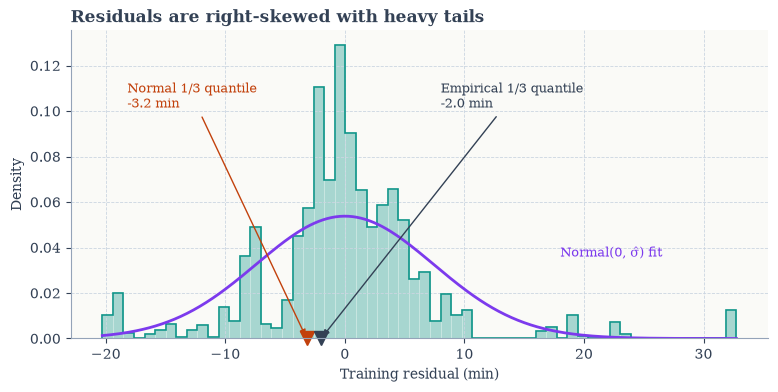

In [7]:
from scipy.stats import skew, kurtosis
print(f"Training residual skewness = {skew(res_tr):.2f}, excess kurtosis = {kurtosis(res_tr):.2f}")
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(res_tr, bins=60, density=True, color=TEAL, alpha=0.35, edgecolor="white", linewidth=0.5)
ax.hist(res_tr, bins=60, density=True, histtype="step", color=TEAL, linewidth=1.2)
xs = np.linspace(res_tr.min(), res_tr.max(), 300); ax.plot(xs, norm.pdf(xs, 0, sigma), color=VIOLET, lw=2)
ymax = ax.get_ylim()[1]
ax.annotate(f"Normal 1/3 quantile\n{z*sigma:.1f} min", xy=(z * sigma, 0), xytext=(z * sigma - 15, ymax * 0.75),
            color=ORANGE, fontsize=9, arrowprops=dict(arrowstyle="-|>", color=ORANGE))
ax.annotate(f"Empirical 1/3 quantile\n{q_emp_res:.1f} min", xy=(q_emp_res, 0), xytext=(q_emp_res + 10, ymax * 0.75),
            color=INK, fontsize=9, arrowprops=dict(arrowstyle="-|>", color=INK))
ax.plot(z * sigma, 0, marker="v", ms=10, color=ORANGE, clip_on=False); ax.plot(q_emp_res, 0, marker="v", ms=10, color=INK, clip_on=False)
ax.text(xs[-1] * 0.55, norm.pdf(xs[-1] * 0.25, 0, sigma) + ymax * 0.05, "Normal(0, σ̂) fit", color=VIOLET, fontsize=9)
ax.set_xlabel("Training residual (min)"); ax.set_ylabel("Density")
ax.set_title("Residuals are right-skewed with heavy tails"); plt.show()

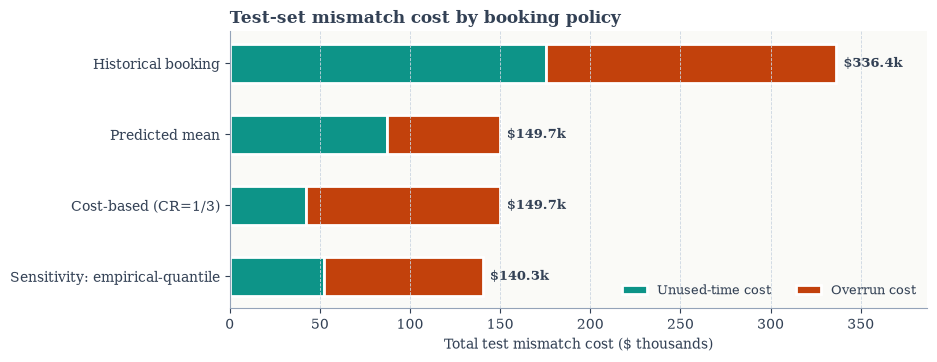

In [8]:
fig, ax = plt.subplots(figsize=(9, 3.6))
unused, over = q1_tab["Unused min"] * Co / 1000, q1_tab["Overrun min"] * Cu / 1000
pos = np.arange(len(q1_tab))[::-1]
ax.barh(pos, unused, color=TEAL, height=0.55, edgecolor="white", linewidth=2, label="Unused-time cost")
ax.barh(pos, over, left=unused, color=ORANGE, height=0.55, edgecolor="white", linewidth=2, label="Overrun cost")
for p_, u, o in zip(pos, unused, over):
    ax.text(u + o + 4, p_, f"${(u + o):,.1f}k", va="center", fontsize=9, fontweight="bold")
ax.set_yticks(pos, q1_tab.index); ax.grid(axis="y", visible=False)
ax.set_xlabel("Total test mismatch cost ($ thousands)"); ax.set_xlim(0, (unused + over).max() * 1.15)
ax.legend(loc="lower right", ncol=2, fontsize=9)
ax.set_title("Test-set mismatch cost by booking policy"); plt.show()

**Comparison:** Both model-based policies cut test mismatch cost by about 56% versus historical bookings (≈ $336k → ≈ $150k), mostly by removing large systematic booking errors.
The Normal cost-based booking is essentially tied with the predicted-mean booking: it trades unused minutes for overrun minutes as intended, but its overrun rate (≈79%) is well above the 2/3 the Normal model implies.
The residuals are right-skewed and heavy-tailed, so the Normal 1/3 quantile (−3.2 min) shifts bookings down too far; the empirical 1/3 quantile of training residuals (≈ −2.0 min) gives a lower test cost.

## 1e. Recommendation
Replace historical bookings with model-based bookings that start from the predicted duration for the case's CPT code, OR suite and weekday, since this alone cuts test mismatch cost by more than half.
Because an unused booked minute ($100) costs twice an overrun minute ($50), book slightly **below** the predicted mean, at the 1/3 quantile of the predictive distribution.
Estimate that quantile from the empirical training residuals (about 2 minutes below the mean) rather than a Normal approximation: the residuals are right-skewed, and the Normal shift over-books short without saving money.
Refit the model regularly, add a fallback for CPT codes not seen in training, and revisit the cost weights, since frequent overruns also carry overtime and patient-delay costs that this model leaves out.

# Question 2 — Two-day sales forecasting

In [9]:
url2 = "https://raw.githubusercontent.com/xuliang-leon/opim348-public-data/main/homework/hw2/product_2003228.csv"
s_df = pd.read_csv(url2)
s_df["sys_date"] = pd.to_datetime(s_df["sys_date"], format="%d/%m/%Y")
s_df = s_df.sort_values("sys_date").reset_index(drop=True)
y = s_df["sales_qty"].astype(float).values
dates = s_df["sys_date"]
n = len(y); n_tr = int(0.6 * n); n_va = int(0.2 * n); n_trva = n_tr + n_va   # 675 / 225 / 226 as in the assignment
print(n, n_tr, n_va, n - n_trva)
print("Train:", dates[0].date(), "to", dates[n_tr-1].date())
print("Valid:", dates[n_tr].date(), "to", dates[n_trva-1].date())
print("Test :", dates[n_trva].date(), "to", dates[n-1].date())
assert (dates.diff().dropna() == pd.Timedelta(days=1)).all()

1126 675 225 226
Train: 2018-01-01 to 2019-11-06
Valid: 2019-11-07 to 2020-06-18
Test : 2020-06-19 to 2021-01-30


## 2a. Exploratory plot and summary

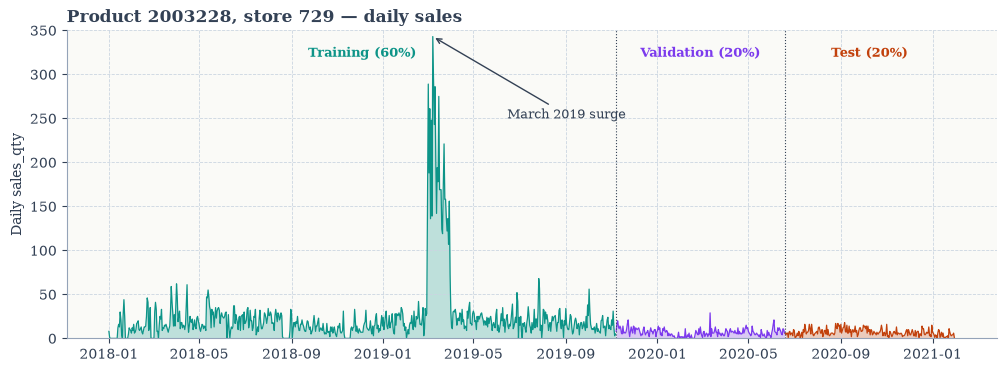

count    1126.00
mean       17.75
std        31.90
min         0.00
25%         6.00
50%        11.00
75%        19.00
max       343.00
dtype: float64
Zero-sales days: 61 (5.4%)
Spike days (> mean + 3 SD = 113.4): 29
  sys_date  sales_qty
2019-03-01        164
2019-03-02        289
2019-03-03        188
2019-03-04        261
2019-03-05        136
2019-03-06        248
2019-03-07        139
2019-03-08        343
2019-03-09        293
2019-03-10        243
2019-03-11        286
2019-03-12        202
2019-03-13        142
2019-03-14        194
2019-03-15        178
2019-03-16        275
2019-03-17        169
2019-03-18        169
2019-03-19        169
2019-03-20        124
2019-03-21        119
2019-03-22        175
2019-03-23        221
2019-03-24        158
2019-03-25        158
2019-03-26        137
2019-03-27        122
2019-03-28        136
2019-03-30        156


In [10]:
fig, ax = plt.subplots(figsize=(12, 4))
for lo, hi, col, lab in [(0, n_tr - 1, TEAL, "Training (60%)"), (n_tr, n_trva - 1, VIOLET, "Validation (20%)"), (n_trva, n - 1, ORANGE, "Test (20%)")]:
    ax.fill_between(dates[lo:hi + 1], y[lo:hi + 1], color=col, alpha=0.25, linewidth=0)
    ax.plot(dates[lo:hi + 1], y[lo:hi + 1], color=col, lw=0.9)
    ax.text(dates[(lo + hi) // 2], 320, lab, color=col, ha="center", fontweight="bold", fontsize=9)
for b in [n_tr, n_trva]:
    ax.axvline(dates[b], color=INK, lw=0.8, ls=":")
ax.annotate("March 2019 surge", xy=(pd.Timestamp("2019-03-08"), 343), xytext=(pd.Timestamp("2019-06-15"), 250),
            fontsize=9, arrowprops=dict(arrowstyle="->", color=INK))
ax.set_ylim(0, 350); ax.set_ylabel("Daily sales_qty"); ax.set_title("Product 2003228, store 729 — daily sales"); plt.show()

summ = pd.Series(y).describe()
print(summ.round(2))
print("Zero-sales days:", int((y == 0).sum()), f"({(y == 0).mean():.1%})")
thr = np.mean(y) + 3 * np.std(y, ddof=1)
print(f"Spike days (> mean + 3 SD = {thr:.1f}):", int((y > thr).sum()))
print(s_df.loc[y > thr, ["sys_date", "sales_qty"]].to_string(index=False))

            mean  median  share zero
dow                                 
Monday     16.38    10.0        0.06
Tuesday    15.35    10.0        0.04
Wednesday  15.47     9.0        0.06
Thursday   14.75    10.0        0.07
Friday     19.01    11.0        0.06
Saturday   23.22    14.0        0.03
Sunday     20.09    12.5        0.05


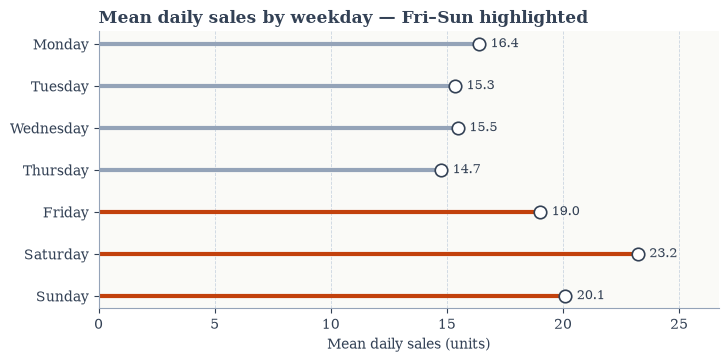

In [11]:
dow = s_df.assign(dow=dates.dt.day_name()).groupby("dow")["sales_qty"].agg(["mean", "median", lambda x: (x == 0).mean()])
dow.columns = ["mean", "median", "share zero"]
dow = dow.reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
print(dow.round(2))
fig, ax = plt.subplots(figsize=(8, 3.6))
cols = [ORANGE if d in ("Friday", "Saturday", "Sunday") else MUTED for d in dow.index]
ax.hlines(dow.index, 0, dow["mean"], color=cols, lw=3)
ax.plot(dow["mean"], dow.index, "o", ms=9, color="white", mec=INK, mew=1.2)
for d, v in dow["mean"].items():
    ax.text(v + 0.5, d, f"{v:.1f}", va="center", fontsize=9)
ax.invert_yaxis(); ax.grid(axis="y", visible=False); ax.set_xlim(0, dow["mean"].max() * 1.15)
ax.set_xlabel("Mean daily sales (units)"); ax.set_title("Mean daily sales by weekday — Fri–Sun highlighted"); plt.show()

In [12]:
blk = pd.Series(np.where(np.arange(n) < n_tr, "Training", np.where(np.arange(n) < n_trva, "Validation", "Test")))
print(pd.DataFrame({"sales": y, "block": blk}).groupby("block", sort=False)["sales"].describe().round(2))

            count   mean    std  min   25%   50%   75%    max
block                                                        
Training    675.0  25.07  39.41  0.0  10.0  16.0  26.0  343.0
Validation  225.0   6.73   4.43  0.0   4.0   6.0   9.0   29.0
Test        226.0   6.87   3.99  0.0   4.0   6.0   9.0   18.0


**Summary:** Daily sales are right-skewed (median 11, mean ≈17.8, max 343). There are 61 zero-sales days (≈5%), spread through the period.
The dominant feature is a one-off surge in **March 2019** (≈120–340 units/day for the whole month), which accounts for all 29 days above mean + 3 SD and lies in the training block.
After that the level falls: validation and test run at only ≈7 units/day, versus ≈25 in the training block.
There is a modest weekly pattern, with Friday–Sunday higher (Saturday mean ≈23 vs ≈15 Tue–Thu).

## 2b–c. Three models and expanding-window rolling validation

In [13]:
H = 2
def forecast(model_name, hist):
    if model_name == "MA7":
        return np.repeat(hist[-7:].mean(), H)
    trend = None if model_name == "ETS seasonal (no trend)" else "add"
    fit = ExponentialSmoothing(hist, trend=trend, seasonal="add", seasonal_periods=7,
                               initialization_method="estimated").fit()
    return fit.forecast(H)

MODELS = ["MA7", "ETS seasonal (no trend)", "ETS trend + seasonal"]

def rolling(first_origin, last_target):
    # origin t = index of last observed day; forecast t+1, t+2; both targets must be <= last_target
    out = []
    for t in range(first_origin, last_target - H + 1):
        hist = y[: t + 1]
        row = {"origin": dates[t], "actual_2d": y[t + 1] + y[t + 2]}
        for m in MODELS:
            row[m] = forecast(m, hist).sum()
        out.append(row)
    return pd.DataFrame(out)

def score(actual, pred):
    e = actual - pred
    return pd.Series({"MAE": np.abs(e).mean(), "RMSE": np.sqrt((e ** 2).mean()), "Mean error (actual-pred)": e.mean()})

val = rolling(n_tr - 1, n_trva - 1)
print("Validation origins:", len(val), val["origin"].iloc[0].date(), "to", val["origin"].iloc[-1].date())
val_tab = pd.DataFrame({m: score(val["actual_2d"], val[m]) for m in MODELS}).T
val_tab.round(3)

Validation origins: 224 2019-11-06 to 2020-06-16


,MAE,RMSE,Mean error (actual-pred)
MA7,4.92,6.57,-0.14
ETS seasonal (no trend),9.83,12.05,-0.10
ETS trend + seasonal,9.79,12.03,-0.07


## 2d. Model selection

Selected model (lowest validation two-day MAE): MA7


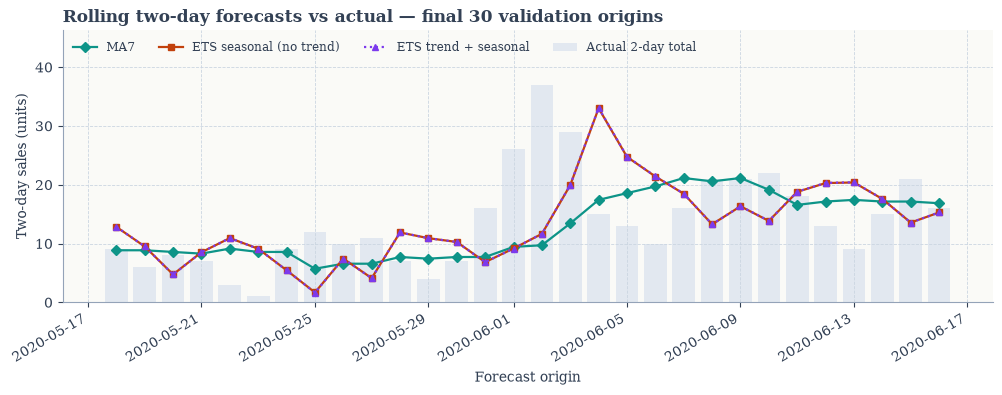

In [14]:
best = val_tab["MAE"].idxmin()
print("Selected model (lowest validation two-day MAE):", best)
last = val.tail(30)
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(last["origin"], last["actual_2d"], color="#E2E8F0", width=0.8, label="Actual 2-day total", zorder=1)
for m, col, mk, ls in zip(MODELS, [TEAL, ORANGE, VIOLET], ["D", "s", "^"], ["-", "-", ":"]):
    ax.plot(last["origin"], last[m], color=col, marker=mk, ms=5, ls=ls, lw=1.6, label=m, zorder=3)
ax.set_xlabel("Forecast origin"); ax.set_ylabel("Two-day sales (units)")
ax.legend(loc="upper left", ncol=4, fontsize=8.5, bbox_to_anchor=(0, 1.0))
ax.set_ylim(0, last[["actual_2d"] + MODELS].values.max() * 1.25)
ax.set_title("Rolling two-day forecasts vs actual — final 30 validation origins"); fig.autofmt_xdate(); plt.show()

**Selection:** MA7 has the lowest validation two-day MAE (≈4.9 vs ≈9.8 for both ETS models) and also the lowest RMSE; all three models have small, slightly negative mean error (mild over-forecasting), so there is no bias trade-off to weigh.
The ETS models lose because their additive weekly seasonal amplitude is learned largely from the high-volume 2018–early 2019 period (including the March 2019 spike), while validation sales run at only ≈7 units/day; the ±7-unit weekly swings they project are as large as the level itself.
Adding a trend does not help. MA7 is robust to this level shift because it uses only the last week.

## 2e. Frozen model on the test block

In [15]:
test2 = []
for t in range(n_trva - 1, n - H):
    test2.append({"origin": dates[t], "actual_2d": y[t + 1] + y[t + 2], best: forecast(best, y[: t + 1]).sum()})
test2 = pd.DataFrame(test2)
print("Test origins:", len(test2))
cmp = pd.DataFrame({"Validation": val_tab.loc[best], "Test": score(test2["actual_2d"], test2[best])}).T
print("Selected model:", best); cmp.round(3)

Test origins: 225
Selected model: MA7


,MAE,RMSE,Mean error (actual-pred)
Validation,4.92,6.57,-0.14
Test,4.85,6.14,-0.12


**Validation vs test:** test MAE/RMSE for MA7 are similar to (slightly better than) validation. Test-period demand has a similar mean to validation but slightly lower day-to-day variability, so the
two-day totals are a little easier to predict; mean error stays near zero, so MA7 remains essentially unbiased. No model was chosen or tuned using test results.

Mean daily sales  — validation: 6.73, test: 6.87
SD daily sales    — validation: 4.43, test: 3.99


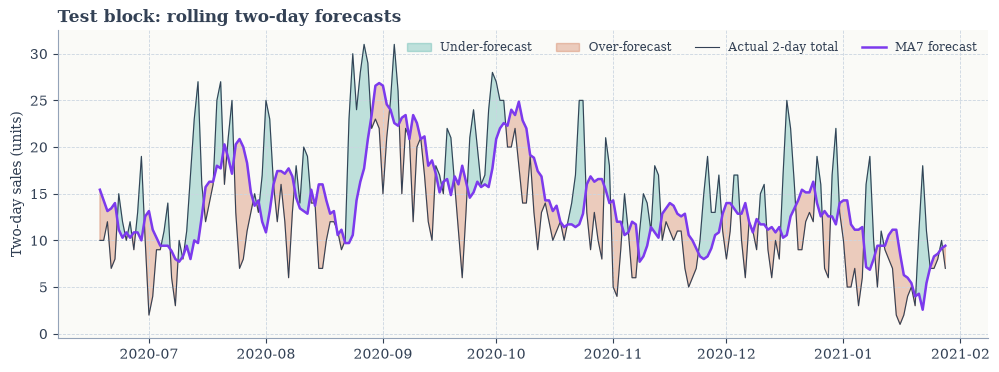

In [16]:
print("Mean daily sales  — validation: %.2f, test: %.2f" % (y[n_tr:n_trva].mean(), y[n_trva:].mean()))
print("SD daily sales    — validation: %.2f, test: %.2f" % (y[n_tr:n_trva].std(ddof=1), y[n_trva:].std(ddof=1)))
fig, ax = plt.subplots(figsize=(12, 4))
err2 = test2["actual_2d"] - test2[best]
ax.fill_between(test2["origin"], test2[best], test2["actual_2d"], where=err2 >= 0, color=TEAL, alpha=0.25, interpolate=True, label="Under-forecast")
ax.fill_between(test2["origin"], test2[best], test2["actual_2d"], where=err2 < 0, color=ORANGE, alpha=0.25, interpolate=True, label="Over-forecast")
ax.plot(test2["origin"], test2["actual_2d"], color=INK, lw=0.8, label="Actual 2-day total")
ax.plot(test2["origin"], test2[best], color=VIOLET, lw=1.8, label=f"{best} forecast")
ax.set_ylabel("Two-day sales (units)"); ax.legend(loc="upper right", ncol=4, fontsize=8.5)
ax.set_title("Test block: rolling two-day forecasts"); plt.show()

# Question 3 — Continuous review (Q, R) policy

## 3a. Demand estimates and EOQ

In [17]:
K, c, i_rate, p_short, L = 10, 1.80, 0.30, 0.20, 2
hist80 = y[:n_trva]
mu_d, sd_d = hist80.mean(), hist80.std(ddof=1)
D_ann = mu_d * 365
Hc = i_rate * c
EOQ = np.sqrt(2 * K * D_ann / Hc)
Q = int(np.ceil(EOQ))
print(f"daily mean = {mu_d:.4f}, daily SD = {sd_d:.4f}")
print(f"D = {D_ann:.2f} units/yr, H = ${Hc:.2f}/unit/yr, EOQ = {EOQ:.2f} -> Q = {Q}")

daily mean = 20.4811, daily SD = 35.1024
D = 7475.61 units/yr, H = $0.54/unit/yr, EOQ = 526.19 -> Q = 527


## 3b. Target cycle service level

In [18]:
CSL = 1 - Hc * Q / (p_short * D_ann)
print("Note: the first 80% includes the March 2019 spike, which inflates the SD:")
print(f"  daily SD excluding March 2019 would be {np.std(hist80[~((dates[:n_trva].dt.year == 2019) & (dates[:n_trva].dt.month == 3)).values], ddof=1):.2f}")
print(f"CSL = 1 - HQ/(pD) = 1 - {Hc:.2f}*{Q}/({p_short}*{D_ann:.2f}) = {CSL:.4f}")

Note: the first 80% includes the March 2019 spike, which inflates the SD:
  daily SD excluding March 2019 would be 10.71
CSL = 1 - HQ/(pD) = 1 - 0.54*527/(0.2*7475.61) = 0.8097


CSL is the probability that **no stockout occurs during a replenishment cycle**, i.e., that lead-time demand does not exceed the reorder point R.
It does not measure the fraction of demand filled (fill rate). With a cheap shortage penalty relative to holding cost per cycle, the target CSL is modest.

## 3c. Normal i.i.d. reorder point

In [19]:
mu_L = L * mu_d
sd_L = np.sqrt(L) * sd_d
zc = norm.ppf(CSL)
SS_norm = zc * sd_L
R_norm = int(np.ceil(mu_L + SS_norm))
print(f"mu_L = {mu_L:.3f}, sigma_L = {sd_L:.3f}, z = {zc:.4f}, SS = {SS_norm:.3f}, R = ceil({mu_L + SS_norm:.3f}) = {R_norm}")

mu_L = 40.962, sigma_L = 49.642, z = 0.8766, SS = 43.519, R = ceil(84.481) = 85


## 3d. Forecast-based safety stock from two-day validation errors
Errors $e = $ actual two-day total $-$ predicted two-day total from the no-trend additive weekly-seasonal ETS (Question 2 rolling validation).
Nearest-rank quantile: sort the $n$ errors, take the $k$-th smallest with $k = \lceil \text{CSL}\cdot n \rceil$. Safety stock $= \max(0, \lceil e_{(k)} \rceil)$.

In [20]:
ets_name = "ETS seasonal (no trend)"
err = np.sort((val["actual_2d"] - val[ets_name]).values)
n_e = len(err)
k = int(np.ceil(CSL * n_e))
q_emp = err[k - 1]
SS_fc = max(0, int(np.ceil(q_emp)))
print(f"n errors = {n_e}, k = {k}, nearest-rank quantile = {q_emp:.3f}, forecast-based SS = {SS_fc}")

n errors = 224, k = 182, nearest-rank quantile = 10.329, forecast-based SS = 11


A two-day error is required because the lead time is exactly two days: once an order is triggered, the stock on hand must cover demand over the **next two days** until the order arrives.
The relevant uncertainty is the error in forecasting that two-day total. One-day errors understate it (variance roughly doubles over two days) and, because errors on consecutive days can be correlated, cannot simply be scaled by √2; using realised two-day errors captures both effects directly.

## 3e. Daily reorder point in the test set
For each test day $t$, at the start of the day (forecast origin = end of day $t-1$, using only sales observed through $t-1$), refit the no-trend weekly-seasonal ETS and forecast demand for days $t$ and $t+1$, the two-day lead time for an order placed on day $t$.

$$R_t = \left\lceil \hat F_{t} + \hat F_{t+1} + SS \right\rceil$$

with $SS$ fixed from 3d. The first test day's origin is the end of the 80% history, so no test actual is used before its day; each later day adds one more observed day. During day $t$, whenever inventory position drops to $R_t$ or below, place an order of $Q$ units. The reorder point varies with the weekly pattern rather than being fixed as in 3c.

In [21]:
rows = []
for t in range(n_trva, n):
    f = forecast(ets_name, y[:t])          # origin = end of day t-1
    rows.append({"Date": dates[t].date(), "Weekday": dates[t].day_name()[:3],
                 "Forecast day t": f[0], "Forecast day t+1": f[1], "2-day forecast": f.sum(),
                 "Safety stock": SS_fc, "Reorder point R_t": int(np.ceil(f.sum() + SS_fc)),
                 "Fixed Normal R": R_norm})
rp = pd.DataFrame(rows)
print("Test days:", len(rp)); print(rp["Reorder point R_t"].describe().round(2))
rp.to_csv("q3e_reorder_points.csv", index=False)
pd.set_option("display.max_rows", 300)
rp.round(2)

Test days: 226
count    226.00
mean      25.34
std        5.91
min       11.00
25%       21.00
50%       24.00
75%       29.00
max       45.00
Name: Reorder point R_t, dtype: float64


,Date,Weekday,Forecast day t,Forecast day t+1,2-day forecast,Safety stock,Reorder point R_t,Fixed Normal R
0,2020-06-19,Fri,6.23,6.03,12.26,11,24,85
1,2020-06-20,Sat,5.91,6.61,12.52,11,24,85
2,2020-06-21,Sun,5.60,6.66,12.26,11,24,85
3,2020-06-22,Mon,6.86,8.44,15.31,11,27,85
4,2020-06-23,Tue,7.99,7.22,15.21,11,27,85
5,2020-06-24,Wed,3.56,1.63,5.19,11,17,85
6,2020-06-25,Thu,3.43,3.00,6.43,11,18,85
7,2020-06-26,Fri,5.38,5.07,10.44,11,22,85
8,2020-06-27,Sat,4.35,5.18,9.53,11,21,85
9,2020-06-28,Sun,6.05,7.02,13.07,11,25,85


**Comparison with 3c:** the forecast-based reorder points average about 25 units, versus a fixed Normal R of 85. The i.i.d. Normal R is driven by the full-history mean (≈20/day) and an SD inflated by the March 2019 spike, while recent demand runs at ≈7/day.
The forecast-based policy tracks the current level and weekly pattern, and its safety stock comes from realised two-day forecast errors.

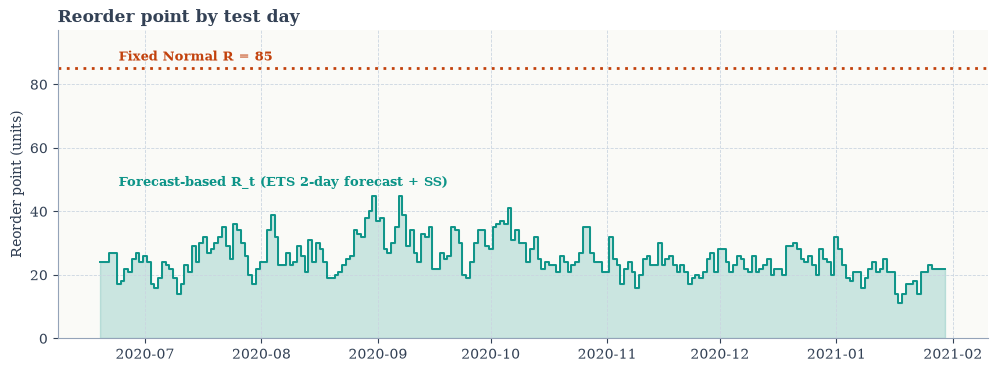

In [22]:
fig, ax = plt.subplots(figsize=(12, 4))
rd = pd.to_datetime(rp["Date"])
ax.fill_between(rd, rp["Reorder point R_t"], step="mid", color=TEAL, alpha=0.2)
ax.step(rd, rp["Reorder point R_t"], where="mid", color=TEAL, lw=1.4)
ax.axhline(R_norm, color=ORANGE, lw=2, ls=(0, (1, 2)))
ax.text(rd.iloc[5], R_norm + 2.5, f"Fixed Normal R = {R_norm}", color=ORANGE, fontweight="bold", fontsize=9)
ax.text(rd.iloc[5], rp["Reorder point R_t"].max() + 3, "Forecast-based R_t (ETS 2-day forecast + SS)", color=TEAL, fontweight="bold", fontsize=9)
ax.set_ylim(0, R_norm + 12); ax.set_ylabel("Reorder point (units)")
ax.set_title("Reorder point by test day"); plt.show()